# User features

One row per user. Behavior columns summarize every rating on the feature movies. Taste columns are the mean movie features of titles the user scored 4 or 5. The saved table keeps users with at least five ratings and at least one high score. EDA below is for choosing a stricter high-score cutoff and which columns to cluster on.

## 1. Load

Load movie features and keep ratings whose `netflix_movie_id` is in that table.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

ROOT = Path("..")
PROCESSED = ROOT / "data" / "processed"

CHUNKSIZE = 2_000_000
MIN_USER_RATINGS = 5
MIN_HIGH_RATINGS = 1
HIGH_RATING = 4
LOW_RATING = 2

movies = pd.read_csv(PROCESSED / "movies_features.csv")
movies["netflix_movie_id"] = movies["netflix_movie_id"].astype(int)
feature_movie_ids = set(movies["netflix_movie_id"])

GENRE_COLS = [c for c in movies.columns if c.startswith("genre_")]
PROD_COLS = [
    "budget_log",
    "log_roi",
    "runtime",
    "movie_age",
    "director_film_count_log",
    "actor_1_film_count_log",
    "actor_2_film_count_log",
    "actor_3_film_count_log",
    "lang_en",
]
LIKED_FEATURE_COLS = GENRE_COLS + PROD_COLS
missing = [c for c in LIKED_FEATURE_COLS if c not in movies.columns]
if missing:
    raise ValueError(f"Missing movie columns: {missing}")

ratings_path = PROCESSED / "ratings.csv"
usecols = ["netflix_movie_id", "customer_id", "rating"]
dtype = {"netflix_movie_id": "int32", "customer_id": "int32", "rating": "int8"}

print(f"Feature movies: {len(feature_movie_ids):,}")
print(f"Genre columns: {len(GENRE_COLS)}")
print(f"Liked feature columns: {len(LIKED_FEATURE_COLS)}")

Feature movies: 1,322
Genre columns: 19
Liked feature columns: 28


## 2. Movie rating mean and std

> **Warning:** `movie avg_rating` and `rating_std` here are computed on **all** ratings. Before clustering, recompute both from **train users only**. Using the all-data values in notebook 04 leaks test users into the movie stats.

In [2]:
stat_parts = []
n_ratings_kept = 0
for chunk in pd.read_csv(ratings_path, usecols=usecols, dtype=dtype, chunksize=CHUNKSIZE):
    chunk = chunk[chunk["netflix_movie_id"].isin(feature_movie_ids)]
    if chunk.empty:
        continue
    n_ratings_kept += len(chunk)
    rating = chunk["rating"].astype("float64")
    tmp = pd.DataFrame(
        {
            "netflix_movie_id": chunk["netflix_movie_id"],
            "count": 1,
            "sum": rating,
            "sumsq": rating * rating,
        }
    )
    stat_parts.append(tmp.groupby("netflix_movie_id", sort=False).sum())

movie_stats = pd.concat(stat_parts).groupby(level=0).sum()
count = movie_stats["count"]
movie_stats["avg_rating"] = movie_stats["sum"] / count
# Sample std. Movies with one rating have no variance.
var = (movie_stats["sumsq"] - (movie_stats["sum"] ** 2) / count) / (count - 1)
movie_stats["rating_std"] = np.sqrt(var.clip(lower=0))
movie_stats.loc[count < 2, "rating_std"] = np.nan
n_lt2 = int((count < 2).sum())
median_std = float(movie_stats["rating_std"].median())
movie_stats["rating_std"] = movie_stats["rating_std"].fillna(median_std)

movie_lookup = movies.set_index("netflix_movie_id")[LIKED_FEATURE_COLS].join(
    movie_stats[["avg_rating", "rating_std"]], how="inner"
)
print(f"Ratings on feature movies: {n_ratings_kept:,}")
print(f"Movies with stats: {len(movie_lookup):,}")
print(f"Movies with <2 ratings (std filled with median {median_std:.4f}): {n_lt2}")
movie_lookup[["avg_rating", "rating_std"]].describe()

Ratings on feature movies: 51,425,714
Movies with stats: 1,322
Movies with <2 ratings (std filled with median 1.0060): 0


,avg_rating,rating_std
count,1322.000000,1322.000000
mean,3.446028,1.013470
std,0.381995,0.092217
min,1.946330,0.712982
25%,3.192976,0.952056
50%,3.460244,1.005985
75%,3.712338,1.072381
max,4.504660,1.326909


## 3. User behavior and liked-movie means

Behavior uses every rating. Taste columns average movie features over ratings of 4 or 5 only. `movie_rating_std` on the user row is the mean polarization of those liked movies. `mean_rating_vs_movie` is the mean of `rating - movie avg_rating` over all of the user's ratings.

In [3]:
behavior_parts = []
liked_parts = []
liked_value_cols = LIKED_FEATURE_COLS + ["movie_rating_std"]

for chunk in pd.read_csv(ratings_path, usecols=usecols, dtype=dtype, chunksize=CHUNKSIZE):
    chunk = chunk[chunk["netflix_movie_id"].isin(feature_movie_ids)]
    if chunk.empty:
        continue
    chunk = chunk.join(movie_lookup, on="netflix_movie_id")
    rating = chunk["rating"].astype("float64")
    behavior = pd.DataFrame(
        {
            "customer_id": chunk["customer_id"].to_numpy(),
            "n_ratings": 1,
            "rating_sum": rating,
            "rating_sumsq": rating * rating,
            "n_high": (rating >= HIGH_RATING).astype("int32"),
            "n_low": (rating <= LOW_RATING).astype("int32"),
            "vs_sum": rating - chunk["avg_rating"].to_numpy(),
        }
    )
    behavior_parts.append(behavior.groupby("customer_id", sort=False).sum())

    liked = chunk.loc[rating >= HIGH_RATING, ["customer_id"] + LIKED_FEATURE_COLS + ["rating_std"]]
    liked = liked.rename(columns={"rating_std": "movie_rating_std"})
    liked_parts.append(liked.groupby("customer_id", sort=False)[liked_value_cols].sum())

behavior = pd.concat(behavior_parts).groupby(level=0).sum()
liked_sums = pd.concat(liked_parts).groupby(level=0).sum()
print(f"Users with a feature-movie rating: {len(behavior):,}")
print(f"Users with at least one rating >= {HIGH_RATING}: {len(liked_sums):,}")

Users with a feature-movie rating: 442,499
Users with at least one rating >= 4: 442,062


## 4. Derived columns, filter, save

Keep users with `n_ratings >= 5` and `n_high >= 1`. Report how many users each rule drops. `genre_entropy` is the entropy of liked genre tags after they are scaled to sum to 1. Movies can carry more than one genre, so this is a tag share, not a share of movies.

In [4]:
n = behavior["n_ratings"]
users = pd.DataFrame(index=behavior.index)
users.index.name = "customer_id"
users["n_ratings"] = n.astype("int32")
users["n_high"] = behavior["n_high"].astype("int32")
users["mean_rating"] = behavior["rating_sum"] / n
user_var = (behavior["rating_sumsq"] - (behavior["rating_sum"] ** 2) / n) / (n - 1)
users["user_rating_std"] = np.sqrt(user_var.clip(lower=0))
users["pct_high"] = behavior["n_high"] / n
users["pct_low"] = behavior["n_low"] / n
users["mean_rating_vs_movie"] = behavior["vs_sum"] / n

liked_means = liked_sums.reindex(users.index)
high = users["n_high"].astype("float64")
liked_means = liked_means.div(high.where(high > 0), axis=0)
users = users.join(liked_means)

genre = users[GENRE_COLS]
genre_mass = genre.sum(axis=1)
share = genre.div(genre_mass.where(genre_mass > 0), axis=0)
share_values = share.to_numpy(dtype="float64")
log_share = np.zeros_like(share_values)
positive = share_values > 0
np.log(share_values, where=positive, out=log_share)
entropy = np.full(len(users), np.nan)
has_tags = genre_mass.to_numpy() > 0
entropy[has_tags] = -(share_values[has_tags] * log_share[has_tags]).sum(axis=1)
users["genre_entropy"] = entropy

n_users = len(users)
fail_ratings = users["n_ratings"] < MIN_USER_RATINGS
fail_high = users["n_high"] < MIN_HIGH_RATINGS
keep = ~fail_ratings & ~fail_high
print(f"Users with a feature-movie rating: {n_users:,}")
print(f"Dropped n_ratings < {MIN_USER_RATINGS}: {int(fail_ratings.sum()):,}")
print(f"Dropped n_high < {MIN_HIGH_RATINGS}: {int(fail_high.sum()):,}")
print(f"Dropped by both rules: {int((fail_ratings & fail_high).sum()):,}")
print(f"Kept: {int(keep.sum()):,}")

eligible = users.loc[~fail_ratings]
print("Users with n_ratings >= 5 by n_high cutoff:")
for cutoff in (1, 5, 10, 20):
    print(f"  n_high >= {cutoff}: {int((eligible['n_high'] >= cutoff).sum()):,}")

user_features = users.loc[keep].reset_index()
col_order = (
    ["customer_id", "n_ratings", "n_high", "mean_rating", "user_rating_std", "pct_high", "pct_low"]
    + LIKED_FEATURE_COLS
    + ["movie_rating_std", "genre_entropy", "mean_rating_vs_movie"]
)
user_features = user_features[col_order]
out_path = PROCESSED / "user_features.csv"
user_features.to_csv(out_path, index=False)
print(f"Saved {out_path.name}: {user_features.shape}")
user_features.head()

Users with a feature-movie rating: 442,499
Dropped n_ratings < 5: 23
Dropped n_high < 1: 437
Dropped by both rules: 4
Kept: 442,043
Users with n_ratings >= 5 by n_high cutoff:
  n_high >= 1: 442,043
  n_high >= 5: 431,528
  n_high >= 10: 390,987
  n_high >= 20: 309,065


Saved user_features.csv: (442043, 38)


,customer_id,n_ratings,n_high,mean_rating,user_rating_std,pct_high,pct_low,genre_action,genre_adventure,genre_animation,...,runtime,movie_age,director_film_count_log,actor_1_film_count_log,actor_2_film_count_log,actor_3_film_count_log,lang_en,movie_rating_std,genre_entropy,mean_rating_vs_movie
0,6,342,149,3.444444,0.793013,0.435673,0.064327,0.342282,0.228188,0.046980,...,123.295302,31.919463,1.521541,2.372844,2.001586,1.883867,0.986577,0.967835,2.620815,-0.183597
1,7,449,309,3.966592,0.928828,0.688196,0.057906,0.288026,0.210356,0.025890,...,123.802589,32.744337,1.446364,2.354231,1.957294,1.769734,0.990291,0.971492,2.465172,0.352971
2,8,68,61,4.279412,0.750037,0.897059,0.014706,0.606557,0.311475,0.016393,...,121.442623,28.819672,1.502371,2.540764,2.020941,1.865186,1.000000,1.008341,2.411149,0.673906
3,10,154,82,3.500000,1.017815,0.532468,0.181818,0.317073,0.231707,0.036585,...,120.024390,28.243902,1.394344,2.390458,2.021462,1.897306,0.963415,1.012886,2.470727,-0.093584
4,25,15,6,3.266667,1.032796,0.400000,0.266667,0.833333,0.166667,0.000000,...,115.500000,25.333333,1.547141,2.557094,1.986931,2.220819,1.000000,0.973744,1.839790,-0.381646


## 5. Coverage

How many users the floor removes, and the shape of `n_ratings` and `n_high`. The high-score histogram is the place to pick a stricter cutoff for clustering without rebuilding the table.

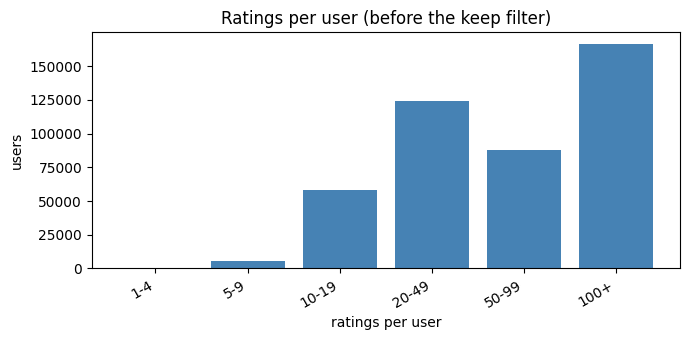

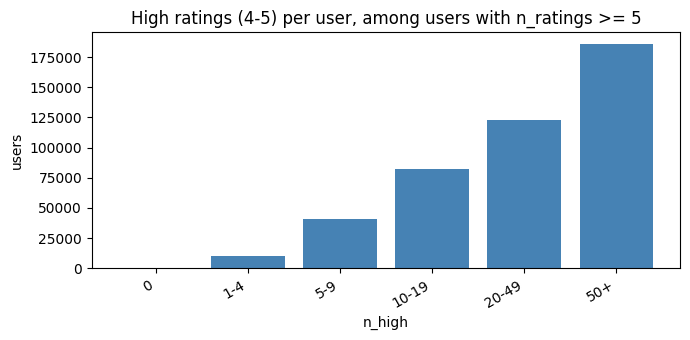

n_high
0           433
1-4       10515
5-9       40541
10-19     81922
20-49    122890
50+      186175
Name: count, dtype: int64

In [5]:
def plot_bucket_counts(series, bins, labels, title, xlabel):
    buckets = pd.cut(series, bins=bins, labels=labels, right=True, include_lowest=True)
    counts = buckets.value_counts().reindex(labels)
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.bar(counts.index.astype(str), counts.values, color="steelblue")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("users")
    ax.set_title(title)
    plt.xticks(rotation=30, ha="right")
    fig.tight_layout()
    plt.show()
    return counts


count_bins = [0.5, 4, 9, 19, 49, 99, np.inf]
count_labels = ["1-4", "5-9", "10-19", "20-49", "50-99", "100+"]
plot_bucket_counts(
    users["n_ratings"],
    bins=count_bins,
    labels=count_labels,
    title="Ratings per user (before the keep filter)",
    xlabel="ratings per user",
)

high_bins = [-0.5, 0, 4, 9, 19, 49, np.inf]
high_labels = ["0", "1-4", "5-9", "10-19", "20-49", "50+"]
plot_bucket_counts(
    eligible["n_high"],
    bins=high_bins,
    labels=high_labels,
    title="High ratings (4-5) per user, among users with n_ratings >= 5",
    xlabel="n_high",
)

## 6. Behavior

How kept users use the 1-5 scale: average score, spread, and the share of high and low ratings.

,mean_rating,user_rating_std,pct_high,pct_low
count,442043.000000,442043.000000,442043.000000,442043.000000
mean,3.659504,0.980369,0.595739,0.143365
std,0.465836,0.240578,0.184790,0.121247
min,1.064246,0.000000,0.004329,0.000000
25%,3.363636,0.822092,0.468354,0.055556
50%,3.657895,0.963191,0.600000,0.115385
75%,3.961538,1.122884,0.728643,0.200000
max,5.000000,2.138090,1.000000,0.983240


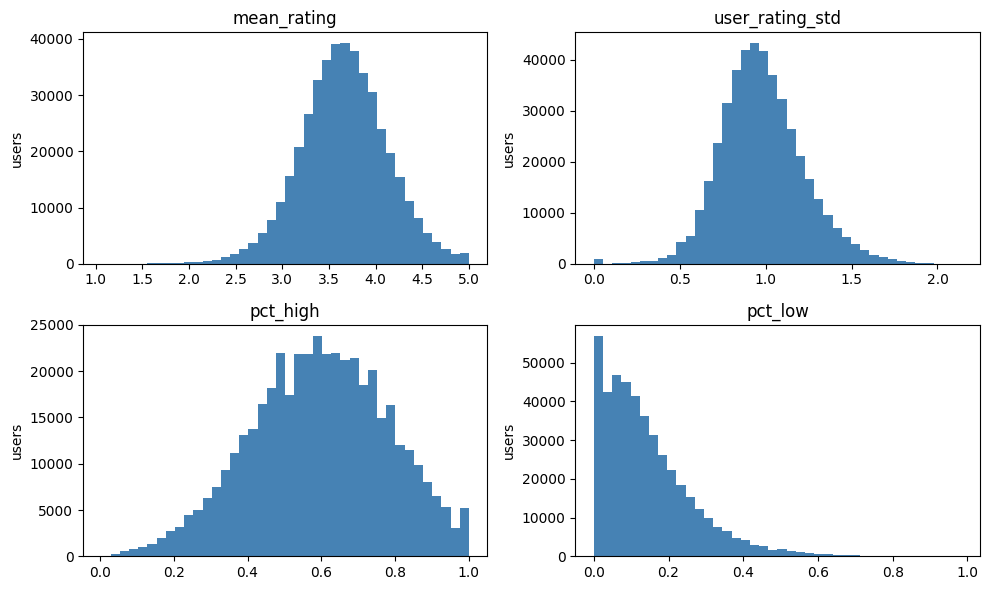

In [6]:
behavior_cols = ["mean_rating", "user_rating_std", "pct_high", "pct_low"]
display(user_features[behavior_cols].describe())

fig, axes = plt.subplots(2, 2, figsize=(10, 6))
for ax, col in zip(axes.ravel(), behavior_cols):
    ax.hist(user_features[col], bins=40, color="steelblue")
    ax.set_title(col)
    ax.set_ylabel("users")
fig.tight_layout()
plt.show()

## 7. Taste spread

Distribution of liked-movie means. A column with almost no spread will not separate personas.

,count,mean,std,min,25%,50%,75%,max
budget_log,442043.0,17.183498,0.581000,0.693147,16.851768,17.285864,17.595397,19.113828
log_roi,442043.0,1.427651,0.354735,-7.257336,1.224993,1.427497,1.632352,15.262430
runtime,442043.0,120.574103,7.268116,72.000000,116.114229,120.223881,124.638889,216.000000
movie_age,442043.0,28.962355,4.393411,21.000000,26.018182,28.367742,31.114583,92.000000
director_film_count_log,442043.0,1.403660,0.154524,0.693147,1.320737,1.412145,1.492642,2.833213
actor_1_film_count_log,442043.0,2.323753,0.222531,0.693147,2.202139,2.331555,2.457553,3.178054
actor_2_film_count_log,442043.0,1.968369,0.182651,0.693147,1.874066,1.974302,2.072545,3.178054
actor_3_film_count_log,442043.0,1.823922,0.163839,0.000000,1.742138,1.826971,1.911763,3.178054
lang_en,442043.0,0.983266,0.041570,0.000000,0.983051,1.000000,1.000000,1.000000
movie_rating_std,442043.0,0.992506,0.034932,0.767848,0.970430,0.990208,1.011681,1.323311


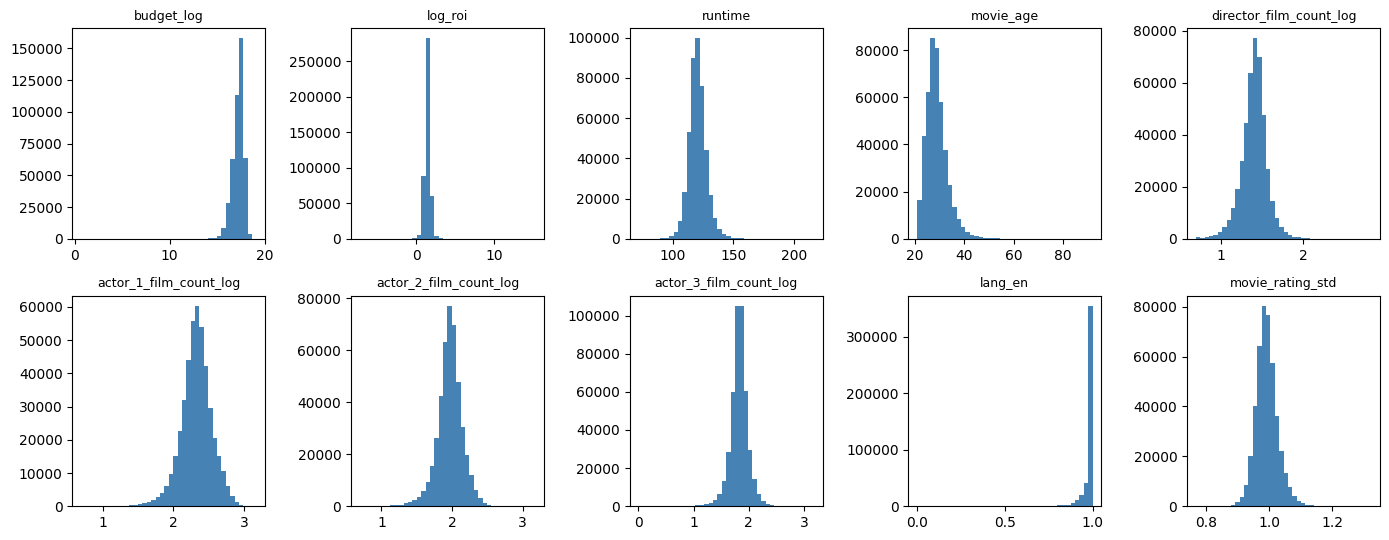

Std of liked-movie means (smallest first):
movie_rating_std           0.034932
lang_en                    0.041570
director_film_count_log    0.154524
actor_3_film_count_log     0.163839
actor_2_film_count_log     0.182651
actor_1_film_count_log     0.222531
log_roi                    0.354735
budget_log                 0.581000
movie_age                  4.393411
runtime                    7.268116


In [7]:
taste_continuous = PROD_COLS + ["movie_rating_std"]
display(user_features[taste_continuous].describe().T)

fig, axes = plt.subplots(2, 5, figsize=(14, 5.5))
for ax, col in zip(axes.ravel(), taste_continuous):
    ax.hist(user_features[col].dropna(), bins=40, color="steelblue")
    ax.set_title(col, fontsize=9)
fig.tight_layout()
plt.show()

spread = user_features[taste_continuous].std().sort_values()
print("Std of liked-movie means (smallest first):")
print(spread.to_string())

## 8. Genre profile

Which genres show up in liked movies for almost everyone, and whether users are specialists or generalists (`genre_entropy`).

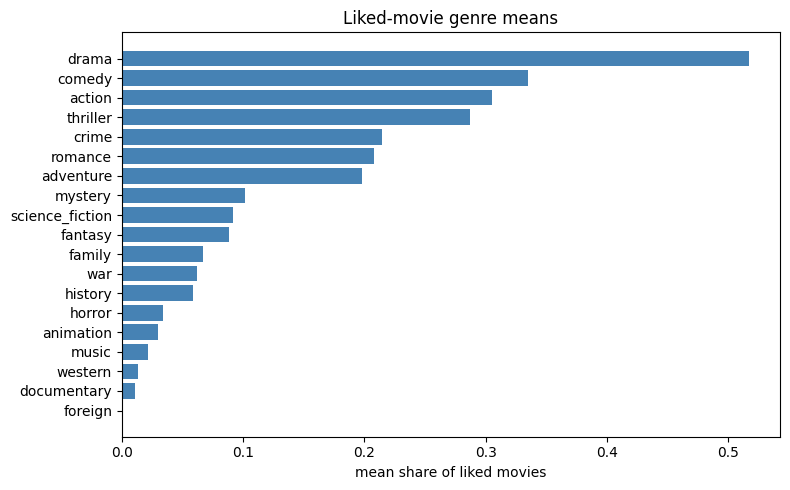

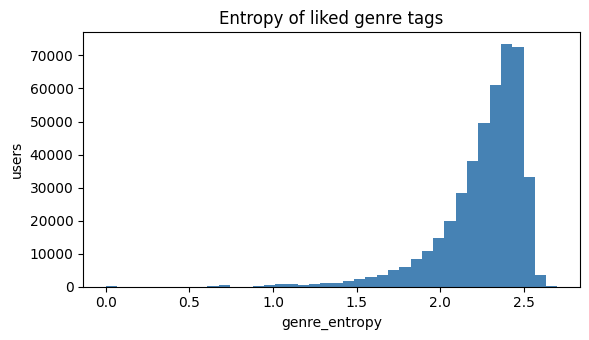

count    442043.000000
mean          2.255603
std           0.257702
min          -0.000000
25%           2.160860
50%           2.322756
75%           2.429783
max           2.700703
Name: genre_entropy, dtype: float64


In [8]:
genre_means = user_features[GENRE_COLS].mean().sort_values()
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(genre_means.index.str.replace("genre_", "", regex=False), genre_means.values, color="steelblue")
ax.set_xlabel("mean share of liked movies")
ax.set_title("Liked-movie genre means")
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(user_features["genre_entropy"].dropna(), bins=40, color="steelblue")
ax.set_xlabel("genre_entropy")
ax.set_ylabel("users")
ax.set_title("Entropy of liked genre tags")
fig.tight_layout()
plt.show()
print(user_features["genre_entropy"].describe())

## 9. Redundancy

Actor film-count logs may move together. `budget_log` and `log_roi` are related by construction. Overlapping genres will correlate.

In [9]:
actor_cols = [
    "actor_1_film_count_log",
    "actor_2_film_count_log",
    "actor_3_film_count_log",
]
print("Actor film-count correlations:")
display(user_features[actor_cols].corr())
print(f"budget_log vs log_roi: {user_features['budget_log'].corr(user_features['log_roi']):.3f}")

genre_corr = user_features[GENRE_COLS].corr()
pairs = []
for i, left in enumerate(GENRE_COLS):
    for right in GENRE_COLS[i + 1 :]:
        pairs.append((left, right, genre_corr.loc[left, right]))
pair_df = pd.DataFrame(pairs, columns=["genre_a", "genre_b", "corr"]).sort_values(
    "corr", key=lambda s: s.abs(), ascending=False
)
print("Strongest genre correlations:")
display(pair_df.head(12))

focus = ["genre_action", "genre_adventure", "genre_horror", "genre_thriller"]
print("Action / adventure / horror / thriller:")
display(user_features[focus].corr())

Actor film-count correlations:


,actor_1_film_count_log,actor_2_film_count_log,actor_3_film_count_log
actor_1_film_count_log,1.000000,0.672105,0.545576
actor_2_film_count_log,0.672105,1.000000,0.522729
actor_3_film_count_log,0.545576,0.522729,1.000000


budget_log vs log_roi: -0.450


Strongest genre correlations:


,genre_a,genre_b,corr
39,genre_animation,genre_family,0.759677
141,genre_history,genre_war,0.697431
0,genre_action,genre_adventure,0.682099
158,genre_mystery,genre_thriller,0.609202
15,genre_action,genre_thriller,0.597850
31,genre_adventure,genre_science_fiction,0.546464
77,genre_crime,genre_thriller,0.541398
22,genre_adventure,genre_drama,-0.528498
61,genre_comedy,genre_romance,0.517742
63,genre_comedy,genre_thriller,-0.504934


Action / adventure / horror / thriller:


,genre_action,genre_adventure,genre_horror,genre_thriller
genre_action,1.000000,0.682099,-0.014969,0.597850
genre_adventure,0.682099,1.000000,-0.022264,0.262589
genre_horror,-0.014969,-0.022264,1.000000,0.200051
genre_thriller,0.597850,0.262589,0.200051,1.000000


## 10. Confound check

Spearman of activity (`n_ratings`) and generosity (`mean_rating`) with the taste columns. A strong link means those behavior columns are leaking into the persona features.

In [10]:
taste_cols = LIKED_FEATURE_COLS + ["movie_rating_std", "genre_entropy"]
confound = pd.DataFrame(
    {
        col: {
            "spearman_n_ratings": user_features["n_ratings"].corr(user_features[col], method="spearman"),
            "spearman_mean_rating": user_features["mean_rating"].corr(
                user_features[col], method="spearman"
            ),
        }
        for col in taste_cols
    }
).T
confound["max_abs"] = confound.abs().max(axis=1)
confound = confound.sort_values("max_abs", ascending=False)
print("Strongest links with n_ratings or mean_rating:")
display(confound.head(15))
flagged = confound[confound["max_abs"] >= 0.3]
print(f"Taste columns with |Spearman| >= 0.3: {len(flagged)}")
if len(flagged):
    display(flagged)

Strongest links with n_ratings or mean_rating:


,spearman_n_ratings,spearman_mean_rating,max_abs
genre_entropy,0.709089,0.121229,0.709089
genre_western,0.474093,0.016644,0.474093
genre_horror,0.461069,0.054148,0.461069
genre_music,0.384492,-0.035162,0.384492
movie_age,0.360020,-0.057941,0.360020
genre_animation,0.336198,0.063587,0.336198
lang_en,-0.322422,0.074087,0.322422
genre_family,0.276774,0.057365,0.276774
movie_rating_std,-0.271523,0.116681,0.271523
genre_documentary,0.269324,-0.046120,0.269324


Taste columns with |Spearman| >= 0.3: 7


,spearman_n_ratings,spearman_mean_rating,max_abs
genre_entropy,0.709089,0.121229,0.709089
genre_western,0.474093,0.016644,0.474093
genre_horror,0.461069,0.054148,0.461069
genre_music,0.384492,-0.035162,0.384492
movie_age,0.360020,-0.057941,0.360020
genre_animation,0.336198,0.063587,0.336198
lang_en,-0.322422,0.074087,0.322422


## 11. Contrarian score

`mean_rating_vs_movie` is positive when the user scores films above the crowd. Compare it with liked-movie polarization and genre entropy.

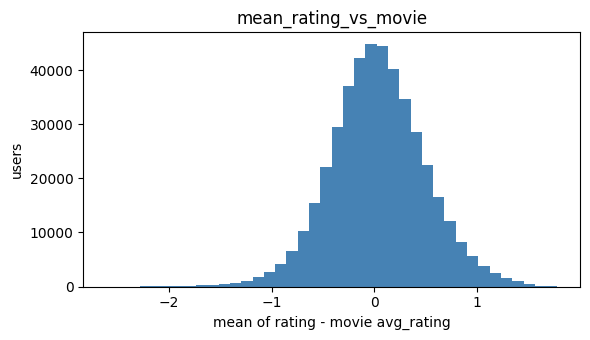

Spearman mean_rating_vs_movie vs movie_rating_std: 0.227
Spearman mean_rating_vs_movie vs genre_entropy: 0.129
count    442043.000000
mean          0.033732
std           0.462131
min          -2.613819
25%          -0.260698
50%           0.025277
75%           0.326711
max           1.779841
Name: mean_rating_vs_movie, dtype: float64


In [11]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(user_features["mean_rating_vs_movie"], bins=40, color="steelblue")
ax.set_xlabel("mean of rating - movie avg_rating")
ax.set_ylabel("users")
ax.set_title("mean_rating_vs_movie")
fig.tight_layout()
plt.show()

for col in ("movie_rating_std", "genre_entropy"):
    rho = user_features["mean_rating_vs_movie"].corr(user_features[col], method="spearman")
    print(f"Spearman mean_rating_vs_movie vs {col}: {rho:.3f}")
print(user_features["mean_rating_vs_movie"].describe())

## 12. Column decision for clustering

The saved table keeps 442,043 users (`n_ratings >= 5` and `n_high >= 1`). Among users with at least five ratings, `n_high >= 5` still leaves 431,528, `n_high >= 10` leaves 390,987, and `n_high >= 20` leaves 309,065. For clustering, require `n_high >= 5` so a persona mean is not one to four titles. That cutoff is applied later; this file stays at the floor of one high rating.

**Keep** as the cluster features: all 19 `genre_*` columns, `budget_log`, `log_roi`, `runtime`, `movie_age`, `director_film_count_log`, and the three `actor_*_film_count_log` columns. Actor correlations are 0.52–0.67, so the billing slots are related and still distinct. `budget_log` and `log_roi` correlate at −0.45. The strongest genre overlaps are animation/family (0.76), history/war (0.70), and action/adventure (0.68); keep both sides of each pair.

**Weak spread, optional:** `lang_en` (mean 0.98, std 0.04) and `movie_rating_std` (mean 0.99, std 0.03). Almost every liked set is English-language, and liked movies sit near the same polarization. Keep `movie_rating_std` only for the variance research question; it will not separate personas on its own.

**Leave out of the cluster matrix:** `n_ratings`, `n_high`, `mean_rating`, `user_rating_std`, `pct_high`, `pct_low`, `genre_entropy`, and `mean_rating_vs_movie`. Generosity barely tracks taste (largest |Spearman| with `mean_rating` is 0.21). `genre_entropy` tracks activity (Spearman 0.71 with `n_ratings`). Rare genre shares (`western`, `horror`, `music`) also rise with `n_ratings` (0.38–0.47), so a later cluster fit should check that heavy raters are not forming their own group.

**Warning:** `movie avg_rating` and `rating_std` in this notebook use all ratings. Recompute both from train users only before notebook 04.

In [12]:
n_at_5 = int((eligible["n_high"] >= 5).sum())
actor_corr = user_features[actor_cols].corr()
actor_off = actor_corr.where(np.triu(np.ones(actor_corr.shape), k=1).astype(bool)).stack()
budget_roi = user_features["budget_log"].corr(user_features["log_roi"])
print(
    f"Clustering cutoff among users with n_ratings >= 5: use n_high >= 5 ({n_at_5:,} users). "
    "This file stays at n_high >= 1."
)
print(
    "Keep: all genre_* , budget_log, log_roi, runtime, movie_age, "
    "director_film_count_log, actor_1/2/3_film_count_log"
)
print(
    "Do not collapse actor columns "
    f"(pairwise corr {actor_off.min():.2f}-{actor_off.max():.2f}) "
    f"or budget_log with log_roi (corr {budget_roi:.2f})."
)
print("Weak spread, optional: lang_en, movie_rating_std")
print(
    "Leave out: n_ratings, n_high, mean_rating, user_rating_std, pct_high, pct_low, "
    "genre_entropy, mean_rating_vs_movie"
)
print("Warning: recompute movie avg_rating and rating_std on train users only before clustering.")

Clustering cutoff among users with n_ratings >= 5: use n_high >= 5 (431,528 users). This file stays at n_high >= 1.
Keep: all genre_* , budget_log, log_roi, runtime, movie_age, director_film_count_log, actor_1/2/3_film_count_log
Do not collapse actor columns (pairwise corr 0.52-0.67) or budget_log with log_roi (corr -0.45).
Weak spread, optional: lang_en, movie_rating_std
Leave out: n_ratings, n_high, mean_rating, user_rating_std, pct_high, pct_low, genre_entropy, mean_rating_vs_movie
